# 🌍 Projekt 1 — Klasifikace satelitních snímků EuroSAT (RGB)

**Cíl projektu:** Multitřídní klasifikace satelitních snímků z družice Sentinel-2 do 10 kategorií využití půdy a zemského pokryvu (Land Use / Land Cover).

**Dataset:** EuroSAT (RGB verze, 27 000 snímků, rozlišení 64×64 px)
**Zdroj:** [Kaggle — EuroSAT Dataset](https://www.kaggle.com/datasets/apollo2506/eurosat-dataset)

---
# ⚙️ 1. Příprava prostředí a načtení dat
> Připojení Google Disku, rozbalení archivu do rychlého lokálního SSD úložiště Colabu, import potřebných knihoven a načtení definic splitů.

In [13]:
# 1.1 Připojení Google Disku a rozbalení EuroSAT.zip do rychlého lokálního SSD
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules or Path("/content").exists()

if IN_COLAB:
    try:
        from google.colab import drive
        if not Path("/content/drive/MyDrive").exists():
            print("Připojuji Google Disk...")
            drive.mount("/content/drive")
        else:
            print("Google Disk je již připojen.")
    except Exception as e:
        print(f"Poznámka k připojení disku: {e}")

    # Kandidátní cesty k EuroSAT.zip na Google Disku
    drive_candidates = [
        Path("/content/drive/MyDrive/Colab Notebooks/ML_project/EuroSAT.zip"),
        Path("/content/drive/MyDrive/Colab Notebooks/EuroSAT.zip"),
        Path("/content/drive/MyDrive/ML_project/EuroSAT.zip"),
        Path("/content/drive/MyDrive/EuroSAT.zip"),
    ]

    zip_file = next((p for p in drive_candidates if p.exists()), None)
    if zip_file is None and Path("/content/drive/MyDrive").exists():
        print("Hledám EuroSAT.zip na Google Disku...")
        found_zips = list(Path("/content/drive/MyDrive").glob("**/EuroSAT.zip"))
        if found_zips:
            zip_file = found_zips[0]

    target_dir = Path("/content/EuroSAT")

    if zip_file is not None:
        print(f"Nalezen archiv: {zip_file}")
        # Rozbalíme pouze pokud na lokálním SSD ještě chybí train.csv
        if not (target_dir / "train.csv").exists():
            print("Rozbaluji EuroSAT.zip na lokální SSD instance (/content/)... Tato operace trvá jen pár sekund.")
            !unzip -q "{zip_file}" -d /content/
            # Pokud byl archiv zabalen bez nadřazené složky EuroSAT, vytvoříme ji
            if not target_dir.exists() and Path("/content/AnnualCrop").exists():
                !mkdir -p /content/EuroSAT
                !mv /content/AnnualCrop /content/Forest /content/HerbaceousVegetation /content/Highway /content/Industrial /content/Pasture /content/PermanentCrop /content/Residential /content/River /content/SeaLake /content/*.csv /content/*.json /content/EuroSAT/ 2>/dev/null || true
            print("Rozbalení dokončeno! Data jsou na rychlém SSD.")
        else:
            print("Dataset je již rozbalen v /content/EuroSAT.")
    else:
        print("VAROVÁNÍ: EuroSAT.zip nebyl nalezen na Google Disku! Zkontrolujte složku na Disku.")
else:
    print("Běžíme lokálně na PC — použije se lokální složka EuroSAT.")


Google Disk je již připojen.
Nalezen archiv: /content/drive/MyDrive/Colab Notebooks/ML_project/EuroSAT.zip
Dataset je již rozbalen v /content/EuroSAT.


In [14]:
# 1.2 Instalace torchinfo (pro vizualizaci architektur neuronových sítí)
try:
    import torchinfo
except ImportError:
    !pip install -q torchinfo
    import torchinfo
print("torchinfo připraveno.")

torchinfo připraveno.


In [15]:
# 1.3 Importy knihoven a Device setup
import os
import numpy as np
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import torch.nn.functional as F
from torchvision import datasets

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_theme(style="whitegrid")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Automatická volba zařízení: GPU (CUDA) v Colabu, CPU lokálně
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch verze:", torch.__version__)
print("Aktivní výpočetní zařízení (Device):", device)

PyTorch verze: 2.11.0+cu128
Aktivní výpočetní zařízení (Device): cuda


In [16]:
# 1.4 Automatické vyhledání cesty k datasetu EuroSAT
candidate_paths = [
    Path("EuroSAT"),          # Lokální složka na PC
    Path("/content/EuroSAT"), # Lokální SSD v Colabu
    Path("/content"),         # Pokud je rozbaleno přímo v /content
]

DATA_DIR = None
for p in candidate_paths:
    if (p / "train.csv").exists():
        DATA_DIR = p
        break

# Fallback: rekurzivní vyhledání train.csv
if DATA_DIR is None:
    search_root = Path("/content") if IN_COLAB else Path(".")
    found = list(search_root.glob("**/train.csv"))
    if found:
        DATA_DIR = found[0].parent

assert DATA_DIR is not None, "Složka s datasetem EuroSAT (obsahující train.csv) nebyla nalezena!"

# Kontrola kompatibility cest v CSV s reálnou složkou obrázků
sample_check = pd.read_csv(DATA_DIR / "train.csv", nrows=1)
sample_fname = sample_check["Filename"].iloc[0]
if not (DATA_DIR / sample_fname).exists():
    if (DATA_DIR / "EuroSAT" / sample_fname).exists():
        DATA_DIR = DATA_DIR / "EuroSAT"
    elif (DATA_DIR.parent / sample_fname).exists():
        DATA_DIR = DATA_DIR.parent

print(f"Dataset EuroSAT úspěšně nalezen a ověřen v: {DATA_DIR.resolve()}")

Dataset EuroSAT úspěšně nalezen a ověřen v: /content/EuroSAT


In [17]:
# 1.5 Načtení definičních CSV souborů splitů (Train / Validation / Test)
train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df   = pd.read_csv(DATA_DIR / "validation.csv")
test_df  = pd.read_csv(DATA_DIR / "test.csv")

total_samples = len(train_df) + len(val_df) + len(test_df)
print(f"Počty vzorků v datasetech:")
print(f"  • Trénovací (Train):      {len(train_df):5d} ({len(train_df)/total_samples:.1%})")
print(f"  • Validační (Validation): {len(val_df):5d} ({len(val_df)/total_samples:.1%})")
print(f"  • Testovací (Test):       {len(test_df):5d} ({len(test_df)/total_samples:.1%})")
print(f"  • Celkem:                 {total_samples:5d}")

Počty vzorků v datasetech:
  • Trénovací (Train):      18900 (70.0%)
  • Validační (Validation):  5400 (20.0%)
  • Testovací (Test):        2700 (10.0%)
  • Celkem:                 27000


---
# 🧪 2. Načtení snímků do PyTorch tenzorů
> Načtení všech 27 000 obrázků ze souborů do paměti RAM a jejich převod do tenzorů tvaru `(N, C, H, W)` normalizovaných do rozsahu `[0.0, 1.0]`. Díky lokálnímu NVMe disku v Colabu trvá načtení jen cca 5–8 sekund.

In [18]:
# 2.1 Načtení obrázků do tenzorů a výpočet základních RGB statistik
def load_split(df, data_dir=DATA_DIR):
    images = [np.array(Image.open(data_dir / fname)) for fname in df["Filename"]]
    # převod: (N, H, W, C) -> (N, C, H, W) normalizováno z [0, 255] do [0.0, 1.0]
    X = torch.from_numpy(np.stack(images)).permute(0, 3, 1, 2).float() / 255.0
    y = torch.tensor(df["Label"].values, dtype=torch.long)
    return X, y

print("Načítám snímky do paměti...")
X_train, y_train = load_split(train_df)
X_val, y_val     = load_split(val_df)
X_test, y_test   = load_split(test_df)

print(f"\nRozměry tenzorů:")
print(f"  • X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"  • X_val:   {X_val.shape}   | y_val:   {y_val.shape}")
print(f"  • X_test:  {X_test.shape}  | y_test:  {y_test.shape}")
print(f"  • Rozsah hodnot pixelů: min={X_train.min().item():.2f}, max={X_train.max().item():.2f}")

# Průměr a směrodatná odchylka přes celou train sadu pro jednotlivé RGB kanály
mean_rgb = X_train.mean(dim=[0, 2, 3])
std_rgb  = X_train.std(dim=[0, 2, 3])
print(f"\nStatistika RGB kanálů v train sadě (pro z-score standardizaci):")
print(f"  • Průměr (Mean):           R={mean_rgb[0]:.4f}, G={mean_rgb[1]:.4f}, B={mean_rgb[2]:.4f}")
print(f"  • Směrodatná odchylka (Std): R={std_rgb[0]:.4f}, G={std_rgb[1]:.4f}, B={std_rgb[2]:.4f}")

Načítám snímky do paměti...

Rozměry tenzorů:
  • X_train: torch.Size([18900, 3, 64, 64]) | y_train: torch.Size([18900])
  • X_val:   torch.Size([5400, 3, 64, 64])   | y_val:   torch.Size([5400])
  • X_test:  torch.Size([2700, 3, 64, 64])  | y_test:  torch.Size([2700])
  • Rozsah hodnot pixelů: min=0.00, max=1.00

Statistika RGB kanálů v train sadě (pro z-score standardizaci):
  • Průměr (Mean):           R=0.3445, G=0.3803, B=0.4078
  • Směrodatná odchylka (Std): R=0.2031, G=0.1371, B=0.1157


---
# 📊 3. Průzkumná analýza dat (EDA)
> V této sekci prozkoumáme klíčové vlastnosti celého datasetu:
> 1. **Vyváženost tříd** napříč jednotlivými splity
> 2. **Vizuální galerie** ukázkových snímků pro všech 10 tříd
> 3. **Distribuce hodnot pixelů** v jednotlivých RGB kanálech
> 4. **Barevné signatury tříd** (jak se liší průměrné barvy např. u lesů, vodních ploch či zástavby)

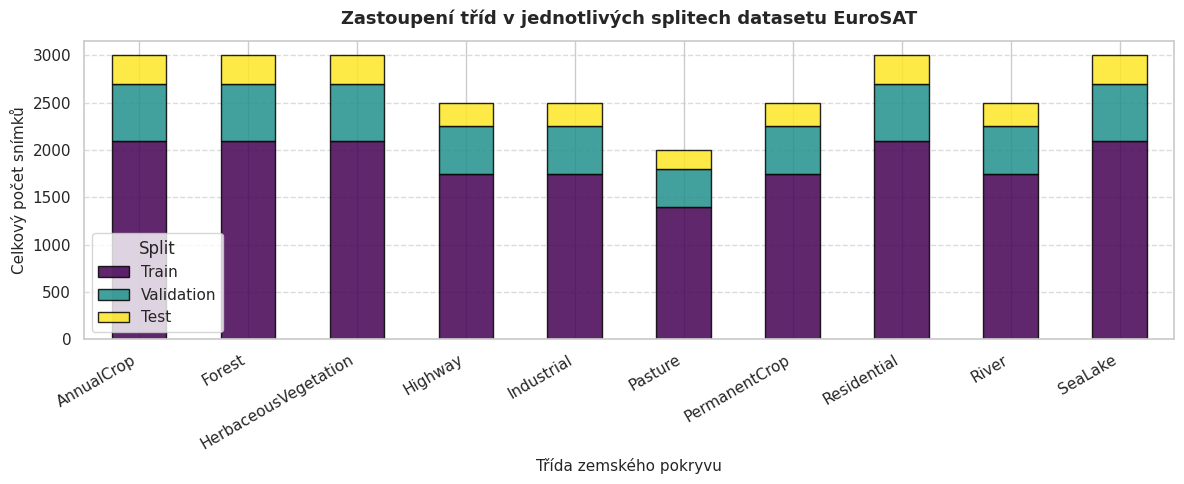

Zastoupení tříd v trénovací sadě:


,Train,Validation,Test
ClassName,,,
AnnualCrop,2100,600,300
Forest,2100,600,300
HerbaceousVegetation,2100,600,300
Highway,1750,500,250
Industrial,1750,500,250
Pasture,1400,400,200
PermanentCrop,1750,500,250
Residential,2100,600,300
River,1750,500,250


In [19]:
# 3.1 Vyváženost tříd napříč trénovací, validační a testovací sadou
split_summary = pd.DataFrame({
    "Train": train_df["ClassName"].value_counts(),
    "Validation": val_df["ClassName"].value_counts(),
    "Test": test_df["ClassName"].value_counts()
}).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(12, 5))
split_summary.plot(kind="bar", stacked=True, ax=ax, colormap="viridis", edgecolor="black", alpha=0.85)
plt.title("Zastoupení tříd v jednotlivých splitech datasetu EuroSAT", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Třída zemského pokryvu", fontsize=11)
plt.ylabel("Celkový počet snímků", fontsize=11)
plt.xticks(rotation=30, ha="right")
plt.legend(title="Split", frameon=True)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

print("Zastoupení tříd v trénovací sadě:")
display(split_summary)

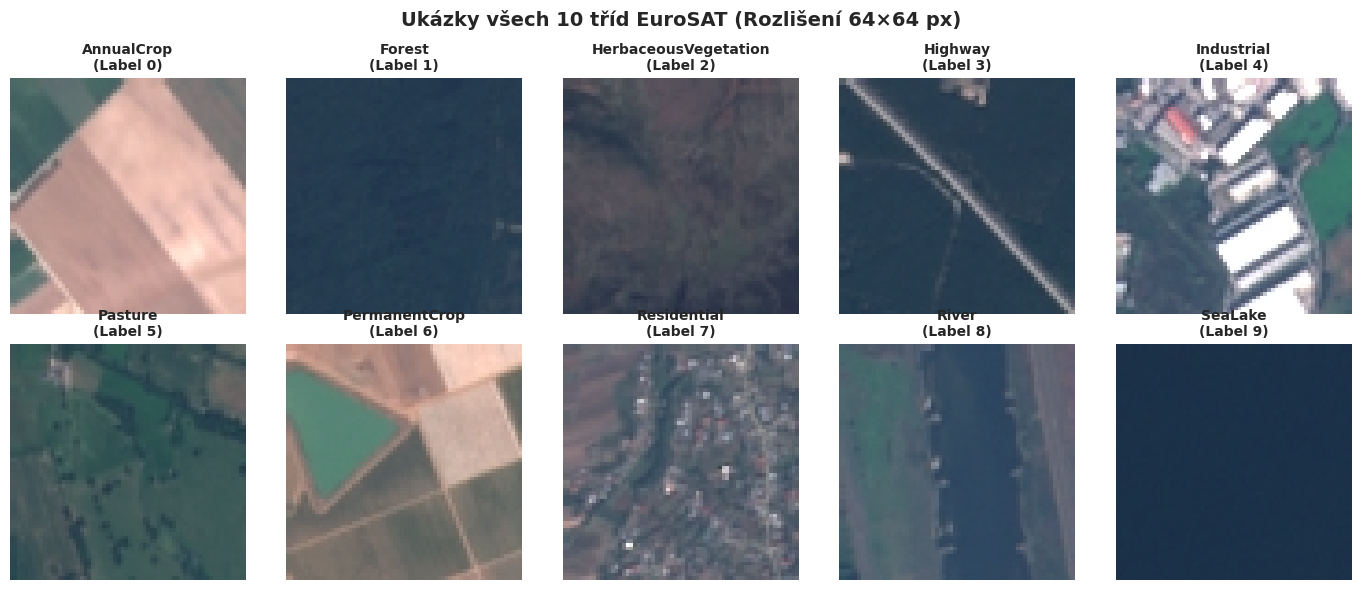

In [20]:
# 3.2 Vykreslení ukázkového snímku pro všech 10 tříd EuroSAT
classes = sorted(train_df["ClassName"].unique())
fig, axes = plt.subplots(2, 5, figsize=(14, 6))

for idx, cls_name in enumerate(classes):
    ax = axes[idx // 5, idx % 5]
    row = train_df[train_df["ClassName"] == cls_name].iloc[0]
    img = Image.open(DATA_DIR / row["Filename"])
    ax.imshow(img)
    ax.set_title(f"{cls_name}\n(Label {row['Label']})", fontsize=10, fontweight="bold")
    ax.axis("off")

plt.suptitle("Ukázky všech 10 tříd EuroSAT (Rozlišení 64×64 px)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

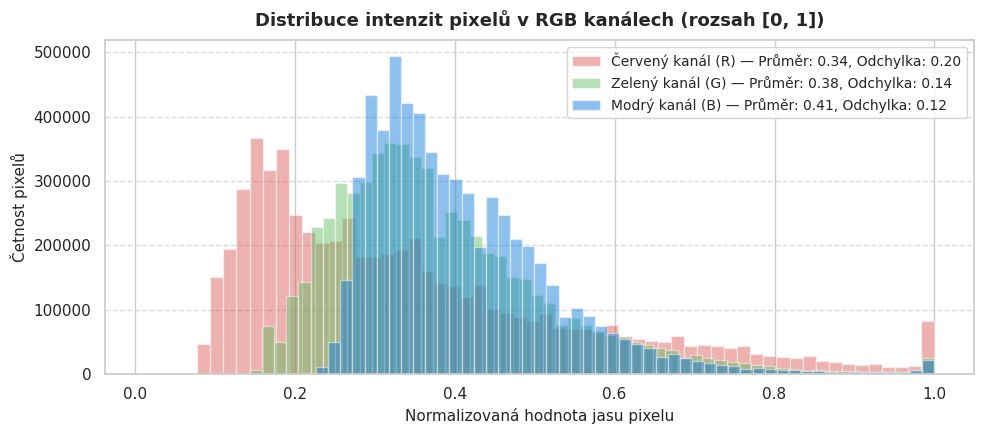

In [21]:
# 3.3 Histogram rozdělení intenzit RGB pixelů v trénovací sadě
# Využijeme reprezentativní výběr 1 500 snímků pro bleskové vykreslení
sample_indices = np.random.choice(len(X_train), size=1500, replace=False)
sample_pixels = X_train[sample_indices]

r_vals = sample_pixels[:, 0, :, :].flatten().numpy()
g_vals = sample_pixels[:, 1, :, :].flatten().numpy()
b_vals = sample_pixels[:, 2, :, :].flatten().numpy()

plt.figure(figsize=(10, 4.5))
plt.hist(r_vals, bins=60, color="#d9534f", alpha=0.45, label=f"Červený kanál (R) — Průměr: {mean_rgb[0]:.2f}, Odchylka: {std_rgb[0]:.2f}")
plt.hist(g_vals, bins=60, color="#5cb85c", alpha=0.45, label=f"Zelený kanál (G) — Průměr: {mean_rgb[1]:.2f}, Odchylka: {std_rgb[1]:.2f}")
plt.hist(b_vals, bins=60, color="#0275d8", alpha=0.45, label=f"Modrý kanál (B) — Průměr: {mean_rgb[2]:.2f}, Odchylka: {std_rgb[2]:.2f}")

plt.title("Distribuce intenzit pixelů v RGB kanálech (rozsah [0, 1])", fontsize=13, fontweight="bold", pad=10)
plt.xlabel("Normalizovaná hodnota jasu pixelu", fontsize=11)
plt.ylabel("Četnost pixelů", fontsize=11)
plt.legend(frameon=True, fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

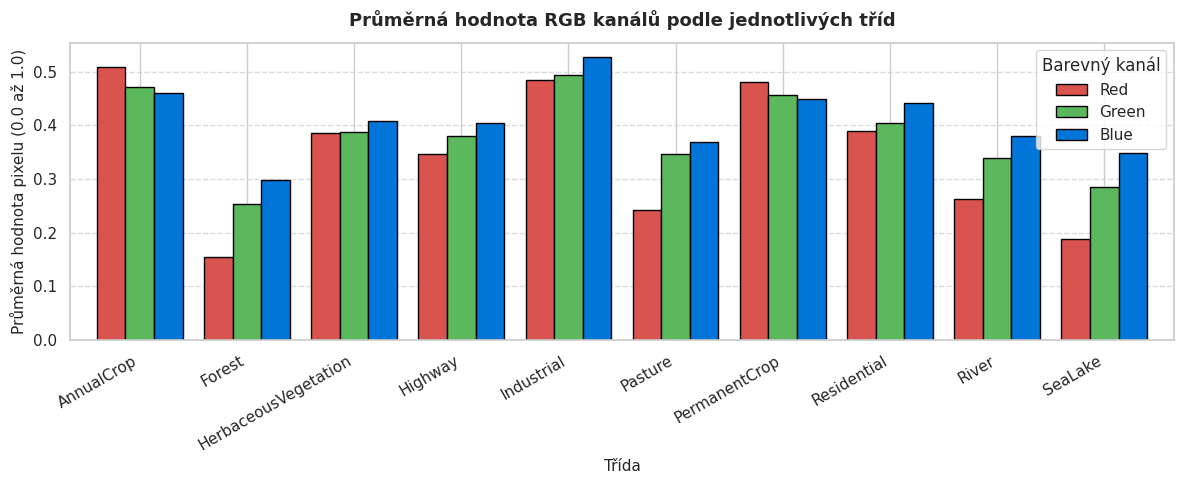

🔎 Klíčové poznatky z průzkumné analýzy (EDA):
  1. Vyváženost tříd: Třídy jsou velmi dobře vyvážené (1400 až 2100 vzorků v train sadě).
  2. Vodní plochy (SeaLake, River): Výrazně dominuje modrý kanál, červený je utlumený.
  3. Vegetace a příroda (Forest, Pasture, Herbaceous): Zřetelná dominance zeleného kanálu.
  4. Zástavba a infrastruktura (Highway, Industrial, Residential): Vyrovnanější RGB hodnoty (šedé tóny).
  => Závěr: Barevné tóny nesou silný klasifikační signál, ale pro jemné odlišení (např. Highway vs Industrial či Forest vs PermanentCrop) bude nezbytné zachytit prostorové tvary a textury pomocí konvolucí (CNN).


In [22]:
# 3.4 Srovnání průměrných barevných profilů podle jednotlivých tříd (RGB Signatures)
# Zjistíme, jak moc se jednotlivé kategorie liší pouhou průměrnou barevností
class_names = [train_df[train_df["Label"] == i]["ClassName"].iloc[0] for i in range(10)]
class_rgb_means = []

for label_idx in range(10):
    mask = (y_train == label_idx)
    rgb_mean = X_train[mask].mean(dim=[0, 2, 3]).numpy()
    class_rgb_means.append(rgb_mean)

df_rgb = pd.DataFrame(class_rgb_means, index=class_names, columns=["Red", "Green", "Blue"])

fig, ax = plt.subplots(figsize=(12, 5))
df_rgb.plot(kind="bar", ax=ax, color=["#d9534f", "#5cb85c", "#0275d8"], edgecolor="black", width=0.8)
plt.title("Průměrná hodnota RGB kanálů podle jednotlivých tříd", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Třída", fontsize=11)
plt.ylabel("Průměrná hodnota pixelu (0.0 až 1.0)", fontsize=11)
plt.xticks(rotation=30, ha="right")
plt.legend(title="Barevný kanál", frameon=True)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

print("🔎 Klíčové poznatky z průzkumné analýzy (EDA):")
print("  1. Vyváženost tříd: Třídy jsou velmi dobře vyvážené (1400 až 2100 vzorků v train sadě).")
print("  2. Vodní plochy (SeaLake, River): Výrazně dominuje modrý kanál, červený je utlumený.")
print("  3. Vegetace a příroda (Forest, Pasture, Herbaceous): Zřetelná dominance zeleného kanálu.")
print("  4. Zástavba a infrastruktura (Highway, Industrial, Residential): Vyrovnanější RGB hodnoty (šedé tóny).")
print("  => Závěr: Barevné tóny nesou silný klasifikační signál, ale pro jemné odlišení (např. Highway vs Industrial"
      " či Forest vs PermanentCrop) bude nezbytné zachytit prostorové tvary a textury pomocí konvolucí (CNN).")

---
# 🚀 4. Příprava DataLoaderů pro trénování modelů
> Standardizace vstupů (z-score normalizace pomocí `mean` a `std`) a sestavení PyTorch `DataLoader` objektů s definovanou velikostí dávky (batch size).

In [23]:
# 4.1 Příprava standardizovaných DataLoaderů pro neuronové sítě
# Provedeme z-score normalizaci: (X - mean) / std
train_dataset = TensorDataset((X_train - mean_rgb.view(1, 3, 1, 1)) / std_rgb.view(1, 3, 1, 1), y_train)
val_dataset   = TensorDataset((X_val - mean_rgb.view(1, 3, 1, 1)) / std_rgb.view(1, 3, 1, 1), y_val)
test_dataset  = TensorDataset((X_test - mean_rgb.view(1, 3, 1, 1)) / std_rgb.view(1, 3, 1, 1), y_test)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"DataLoadery úspěšně připraveny (Batch size: {BATCH_SIZE}):")
print(f"  • Train batche: {len(train_loader):3d} (celkem {len(train_dataset)} snímků)")
print(f"  • Val batche:   {len(val_loader):3d} (celkem {len(val_dataset)} snímků)")
print(f"  • Test batche:  {len(test_loader):3d} (celkem {len(test_dataset)} snímků)")

DataLoadery úspěšně připraveny (Batch size: 64):
  • Train batche: 296 (celkem 18900 snímků)
  • Val batche:    85 (celkem 5400 snímků)
  • Test batche:   43 (celkem 2700 snímků)
